# 08. Robustness, uncertainty, and final paper outputs

This notebook reproduces the post-specification robustness analyses and final paper-facing policy outputs. It never overwrites the frozen empirical-Bayes main policy artifact. Behavioral-parameter ranges condition on selected calendars and exclude calendar-selection, PPML-estimation, planning-origin, and historical-state uncertainty.

**Inputs:** the empirical-Bayes policy artifact from Notebook 06. **Outputs:** final policy tables, Figures 2-3, robustness summaries, and fixed-calendar behavioral-parameter uncertainty.

In [1]:
from pathlib import Path
import pandas as pd
import sys

CURRENT_DIR = Path.cwd().resolve()
PROJECT_ROOT = next((p for p in [CURRENT_DIR, *CURRENT_DIR.parents] if (p / 'pyproject.toml').is_file()), None)
if PROJECT_ROOT is None:
    raise FileNotFoundError('Run from the repository or notebooks directory.')
EB_VERSION = 'empirical_bayes_price_consistent'
MAIN_ARTIFACT = PROJECT_ROOT / 'artifacts' / 'policy' / EB_VERSION / 'policy_optimization.pkl'
ROBUSTNESS_DIR = PROJECT_ROOT / 'results' / EB_VERSION / 'robustness'
assert MAIN_ARTIFACT.exists(), 'EB main policy artifact is missing. Run Notebook 06 first.'
ROBUSTNESS_DIR.mkdir(parents=True, exist_ok=True)
SCRIPTS_DIR = PROJECT_ROOT / 'scripts'
if str(SCRIPTS_DIR) not in sys.path:
    sys.path.insert(0, str(SCRIPTS_DIR))

## Diagnostics / validation

### Optional Figure 2 zoom: reimbursement share 0.50-1.00

This view defers until the Task-8 reporting grid exists.

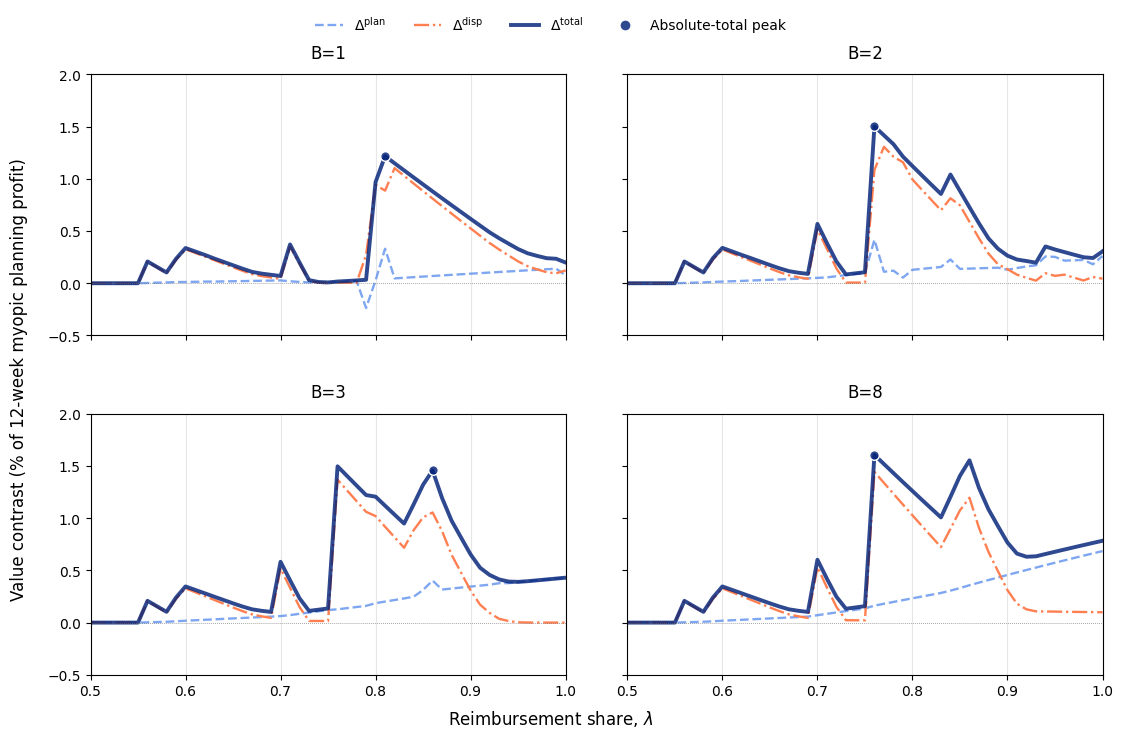

Saved: C:\Users\janza\Desktop\dynamic_promotion_planning_renamed_workflow_0.3.0\results\empirical_bayes_price_consistent\figures\three_policy_components_by_capacity_lambda_050_to_100.png


In [2]:
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
import numpy as np

TABLE_DIR = PROJECT_ROOT / 'results' / EB_VERSION / 'tables'
FIGURE_DIR = PROJECT_ROOT / 'results' / EB_VERSION / 'figures'
FIGURE_DIR.mkdir(parents=True, exist_ok=True)

if not (TABLE_DIR / 'task8_three_policy_reporting_grid.csv').is_file():
    print('Deferred optional 12-week zoom until Task-8 reporting exists.')
else:
    zoom_grid = pd.read_csv(TABLE_DIR / 'task8_three_policy_reporting_grid.csv')
    zoom_grid = zoom_grid.loc[
        zoom_grid['specification'].eq('main')
        & zoom_grid['reimbursement_share'].between(0.50, 1.00)
    ].copy()
    if zoom_grid.empty:
        raise RuntimeError('No main-specification Task-8 rows are available for the requested zoom.')

    components = [
        ('delta_plan_pct', r'$\Delta^{\mathrm{plan}}$', '#6494EDD3', '--', 1.7),
        ('delta_disp_pct', r'$\Delta^{\mathrm{disp}}$', 'coral', '-.', 1.7),
        ('delta_total_pct', r'$\Delta^{\mathrm{total}}$', '#022278D2', '-', 2.8),
    ]
    fig, axes = plt.subplots(2, 2, figsize=(11.5, 7.6), sharex=True, sharey=True)
    for ax, capacity in zip(axes.flat, [1, 2, 3, 8]):
        group = zoom_grid.loc[zoom_grid['capacity'].eq(capacity)].sort_values('reimbursement_share')
        if group.empty:
            raise RuntimeError(f'Missing B={capacity} from the Task-8 reporting grid.')
        for column, _label, color, linestyle, linewidth in components:
            ax.plot(group['reimbursement_share'], group[column], color=color, linestyle=linestyle, linewidth=linewidth)
        # Select the marker by absolute delta_total; plot its 12-week-normalized height.
        peak = group.loc[group['delta_total'].idxmax()]
        ax.scatter(peak['reimbursement_share'], peak['delta_total_pct'], s=48, color='#022278D2', edgecolor='white', linewidth=1.0, zorder=5)
        ax.axhline(0, color='0.45', linewidth=0.55, linestyle=':')
        ax.set_title(f'B={capacity}', pad=12)
        ax.set_xlim(0.50, 1.00)
        ax.set_xticks(np.arange(0.50, 1.01, 0.10))
        ax.set_ylim(-0.5, 2)
        ax.grid(axis='x', color='0.90', linewidth=0.8)

    fig.supxlabel(r'Reimbursement share, $\lambda$', y=0.04)
    fig.supylabel('Value contrast (% of 12-week myopic planning profit)', x=0.03)
    legend_handles = [
        Line2D([0], [0], color=color, linestyle=linestyle, linewidth=linewidth, label=label)
        for _column, label, color, linestyle, linewidth in components
    ] + [
        Line2D([0], [0], marker='o', color='none', markerfacecolor='#022278D2', markeredgecolor='white', markersize=8, label='Absolute-total peak')
    ]
    fig.legend(handles=legend_handles, loc='upper center', ncol=4, frameon=False, bbox_to_anchor=(0.5, 0.995))
    fig.subplots_adjust(left=0.10, right=0.98, top=0.90, bottom=0.11, hspace=0.30, wspace=0.13)
    zoom_path = FIGURE_DIR / 'three_policy_components_by_capacity_lambda_050_to_100.png'
    fig.savefig(zoom_path, dpi=300)
    display(fig)
    plt.close(fig)
    print(f'Saved: {zoom_path}')

### Figure 2 availability check

The canonical Figure 2 is generated and displayed once under Main paper outputs below.

In [3]:
same_horizon_grid_path = PROJECT_ROOT / 'results' / EB_VERSION / 'robustness' / 'same_horizon_normalization_full_grid.csv'
if same_horizon_grid_path.is_file():
    print('A saved 48-week reporting grid is available for the canonical Figure 2 below.')
else:
    print('Deferred optional 48-week view until same-horizon reporting exists.')


A saved 48-week reporting grid is available for the canonical Figure 2 below.


## Robustness computations and reporting inputs

The first computation reoptimizes pooled-displacement, influential-product, and three-week-cooldown specifications, constructs reporting denominators, and creates final policy figures. It does not refit PPML. The second fits the alternative `product_promotion` PPML profile and reoptimizes the policy grid; it is the longest step. All write only to versioned robustness paths.

In [4]:
# Reoptimize the prespecified robustness cases, construct the 12-week and
# same-horizon 48-week reporting measures, and then build Figures 2-3.
import subprocess

task7_artifact = MAIN_ARTIFACT.parent / "task7_robustness_runs.pkl"
if task7_artifact.is_file():
    print(f"Reusing completed Task 7 artifact: {task7_artifact}")
else:
    subprocess.run(
        [sys.executable, str(SCRIPTS_DIR / "run_task7_robustness.py")],
        cwd=PROJECT_ROOT,
        check=True,
    )

task8_outputs = [
    ROBUSTNESS_DIR / "same_horizon_normalization_full_grid.csv",
    ROBUSTNESS_DIR / "fixed_calendar_behavioral_uncertainty_peak_summary.csv",
]
if all(path.is_file() for path in task8_outputs):
    print("Reusing completed Task 8 reporting outputs.")
else:
    subprocess.run([sys.executable, str(SCRIPTS_DIR / "run_task8_reporting_checks.py")], cwd=PROJECT_ROOT, check=True)

subprocess.run([sys.executable, str(SCRIPTS_DIR / "build_three_policy_figures.py")], cwd=PROJECT_ROOT, check=True)


Reusing completed Task 7 artifact: C:\Users\janza\Desktop\dynamic_promotion_planning_renamed_workflow_0.3.0\artifacts\policy\empirical_bayes_price_consistent\task7_robustness_runs.pkl
Reusing completed Task 8 reporting outputs.


CompletedProcess(args=['C:\\Users\\janza\\AppData\\Local\\Programs\\Python\\Python313\\python.exe', 'C:\\Users\\janza\\Desktop\\dynamic_promotion_planning_renamed_workflow_0.3.0\\scripts\\build_three_policy_figures.py'], returncode=0)

### Three-week spacing robustness

This reoptimizes all three policies under the stricter `P, 0, 0, 0, P` feasible-calendar rule. It preserves every other frozen empirical-Bayes input and writes only to a separate robustness path.

In [5]:
# Reuse the separately versioned completed cooldown robustness when present.
cooldown_dir = ROBUSTNESS_DIR / "cooldown_3_weeks"
cooldown_required = [
    cooldown_dir / "cooldown_3_weeks_full_grid.csv",
    cooldown_dir / "cooldown_3_weeks_peak_summary.csv",
]
if all(path.is_file() for path in cooldown_required):
    print(f"Reusing completed cooldown-3 robustness: {cooldown_dir}")
else:
    subprocess.run(
        [sys.executable, str(SCRIPTS_DIR / "run_cooldown_3_weeks_robustness.py")],
        cwd=PROJECT_ROOT,
        check=True,
    )


Reusing completed cooldown-3 robustness: C:\Users\janza\Desktop\dynamic_promotion_planning_renamed_workflow_0.3.0\results\empirical_bayes_price_consistent\robustness\cooldown_3_weeks


In [6]:
# Same-horizon normalization and fixed-calendar behavioral-parameter
# uncertainty. Reuse completed outputs when available; this section neither
# refits PPML nor reoptimizes calendars.
reporting_paths = {
    'same_horizon_grid': ROBUSTNESS_DIR / 'same_horizon_normalization_full_grid.csv',
    'normalization_peaks': ROBUSTNESS_DIR / 'same_horizon_normalization_peak_summary.csv',
    'parent_level_contrasts': ROBUSTNESS_DIR / 'fixed_calendar_behavioral_uncertainty_peak_draws.csv',
    'uncertainty_peaks': ROBUSTNESS_DIR / 'fixed_calendar_behavioral_uncertainty_peak_summary.csv',
}
if all(path.is_file() for path in reporting_paths.values()):
    same_horizon_grid = pd.read_csv(reporting_paths['same_horizon_grid'])
    normalization_peaks = pd.read_csv(reporting_paths['normalization_peaks'])
    parent_level_contrasts = pd.read_csv(reporting_paths['parent_level_contrasts'])
    uncertainty_peaks = pd.read_csv(reporting_paths['uncertainty_peaks'])
    print('Reusing completed Task 8 normalization and fixed-calendar uncertainty outputs.')
else:
    from run_final_robustness_reporting import run_reporting_robustness

    reporting_results = run_reporting_robustness()
    same_horizon_grid = reporting_results['same_horizon_grid']
    normalization_peaks = reporting_results['same_horizon_peaks']
    parent_level_contrasts = reporting_results['fixed_calendar_parent_contrasts']
    uncertainty_peaks = reporting_results['fixed_calendar_summary']
    print(f"Completed normalization and fixed-calendar uncertainty in {reporting_results['runtime_seconds']:.1f} seconds.")

Reusing completed Task 8 normalization and fixed-calendar uncertainty outputs.


In [7]:
# B: execute the expensive PPML fit, common-origin profile, and full reoptimization in-kernel.
# It reuses final behavioral draws/actions and writes only under robustness paths.
from run_alternative_ppml_robustness import ARTIFACTS as ALTERNATIVE_ARTIFACT_DIR, OUT as ALTERNATIVE_OUTPUT_DIR, run_alternative_ppml_robustness
from dynamic_promotion_planning.policy import load_pickle

alternative_artifact = load_pickle(ALTERNATIVE_ARTIFACT_DIR / "policy_optimization.pkl")
alternative_prediction_grid = None
alternative_weekly_profile = alternative_artifact["weekly_profile_table"]
alternative_policy_grid = pd.read_csv(ALTERNATIVE_OUTPUT_DIR / "alternative_ppml_full_grid.csv")
alternative_summary = pd.read_csv(ALTERNATIVE_OUTPUT_DIR / "alternative_ppml_peak_transition_summary.csv")
alternative_vs_main = pd.read_csv(ALTERNATIVE_OUTPUT_DIR / "alternative_ppml_vs_main_full_grid.csv")
display(alternative_summary)
print(f"Reusing completed alternative-PPML robustness: {ALTERNATIVE_ARTIFACT_DIR}")

,specification,capacity,peak_delta_total,peak_lambda,peak_delta_plan,peak_delta_disp,displacement_share_at_peak,piM_transitions,piN_transitions,piD_transitions,piM_transition_locations,piN_transition_locations,piD_transition_locations
0,alternative_product_promotion,1,2173.629887,0.80,584.534864,1589.095023,0.731079,9,10,12,0.56|0.59|0.60|0.63|0.71|0.74|0.79|0.80|0.93,0.56|0.59|0.60|0.63|0.71|0.72|0.74|0.79|0.81|0.93,0.60|0.65|0.67|0.68|0.72|0.73|0.74|0.76|0.82|0...
1,alternative_product_promotion,2,2557.007349,0.76,167.260757,2389.746592,0.934587,13,17,15,0.56|0.59|0.60|0.63|0.70|0.71|0.76|0.79|0.84|0...,0.56|0.59|0.60|0.63|0.70|0.71|0.76|0.79|0.84|0...,0.60|0.65|0.66|0.67|0.68|0.72|0.73|0.88|0.89|0...
2,alternative_product_promotion,3,2711.333030,0.86,718.379684,1992.953346,0.735046,12,14,15,0.56|0.59|0.60|0.70|0.71|0.76|0.79|0.84|0.85|0...,0.56|0.59|0.60|0.70|0.71|0.76|0.79|0.84|0.85|0...,0.60|0.65|0.66|0.67|0.68|0.71|0.72|0.73|0.88|0...
3,alternative_product_promotion,8,2864.949797,0.86,615.710521,2249.239276,0.785089,8,8,14,0.56|0.59|0.60|0.70|0.76|0.84|0.85|0.86,0.56|0.59|0.60|0.70|0.76|0.84|0.85|0.86,0.60|0.65|0.66|0.67|0.68|0.71|0.72|0.73|0.88|0...


Reusing completed alternative-PPML robustness: C:\Users\janza\Desktop\dynamic_promotion_planning_renamed_workflow_0.3.0\artifacts\robustness\empirical_bayes_price_consistent\alternative_ppml_product_promotion


## A. Same-horizon normalization

The 12-week myopic-planning-profit percentage remains the operational primary measure. The 48-week percentage is reported only as a same-horizon normalization.

In [8]:
display(normalization_peaks)

,reimbursement_share,capacity,myopic_planning_profit_12w,myopic_profit_48w,delta_plan,delta_plan_pct_myopic_planning_12w,delta_plan_pct_myopic_same_horizon_48w,delta_disp,delta_disp_pct_myopic_planning_12w,delta_disp_pct_myopic_same_horizon_48w,delta_total,delta_total_pct_myopic_planning_12w,delta_total_pct_myopic_same_horizon_48w
0,0.81,1,158593.194404,583858.227172,524.225108,0.330547,0.089786,1406.419777,0.886810,0.240884,1930.644884,1.217357,0.330670
1,0.76,2,156569.516762,581698.486116,652.095300,0.416489,0.112102,1699.487481,1.085452,0.292160,2351.582781,1.501942,0.404261
2,0.86,3,160816.347092,585960.385813,646.881691,0.402249,0.110397,1696.053757,1.054653,0.289449,2342.935448,1.456901,0.399845
3,0.76,8,155867.818571,581568.421609,253.515318,0.162648,0.043592,2249.326797,1.443099,0.386769,2502.842114,1.605747,0.430361


## B. Alternative demand-model robustness

This uses the simpler `product_promotion` PPML profile but retains the frozen behavioral draws, actions, economics, initialization, horizon, and optimizer.

In [9]:
display(alternative_summary)

,specification,capacity,peak_delta_total,peak_lambda,peak_delta_plan,peak_delta_disp,displacement_share_at_peak,piM_transitions,piN_transitions,piD_transitions,piM_transition_locations,piN_transition_locations,piD_transition_locations
0,alternative_product_promotion,1,2173.629887,0.80,584.534864,1589.095023,0.731079,9,10,12,0.56|0.59|0.60|0.63|0.71|0.74|0.79|0.80|0.93,0.56|0.59|0.60|0.63|0.71|0.72|0.74|0.79|0.81|0.93,0.60|0.65|0.67|0.68|0.72|0.73|0.74|0.76|0.82|0...
1,alternative_product_promotion,2,2557.007349,0.76,167.260757,2389.746592,0.934587,13,17,15,0.56|0.59|0.60|0.63|0.70|0.71|0.76|0.79|0.84|0...,0.56|0.59|0.60|0.63|0.70|0.71|0.76|0.79|0.84|0...,0.60|0.65|0.66|0.67|0.68|0.72|0.73|0.88|0.89|0...
2,alternative_product_promotion,3,2711.333030,0.86,718.379684,1992.953346,0.735046,12,14,15,0.56|0.59|0.60|0.70|0.71|0.76|0.79|0.84|0.85|0...,0.56|0.59|0.60|0.70|0.71|0.76|0.79|0.84|0.85|0...,0.60|0.65|0.66|0.67|0.68|0.71|0.72|0.73|0.88|0...
3,alternative_product_promotion,8,2864.949797,0.86,615.710521,2249.239276,0.785089,8,8,14,0.56|0.59|0.60|0.70|0.76|0.84|0.85|0.86,0.56|0.59|0.60|0.70|0.76|0.84|0.85|0.86,0.60|0.65|0.66|0.67|0.68|0.71|0.72|0.73|0.88|0...


## Main paper outputs

### Table 4 - Robustness of peak total policy contrasts

Each cell reports $\lambda^*$, followed in parentheses by the peak $\Delta^{\mathrm{total}}$ as a percentage of the corresponding specification-specific 48-week myopic profit. $\lambda^*$ maximizes dollar $\Delta^{\mathrm{total}}$ on the 0.01 reimbursement grid.

In [10]:
from build_robustness_peak_table import build_robustness_peak_table
from build_paper_tables import build_paper_tables

robustness_peak_long, robustness_peak_table = build_robustness_peak_table()
table4_path = TABLE_DIR / "robustness_peak_location_and_magnitude.csv"
pd.testing.assert_frame_equal(
    robustness_peak_table.reset_index(drop=True),
    pd.read_csv(table4_path).reset_index(drop=True),
    check_dtype=False,
    check_names=False,
)
paper_tables = build_paper_tables()
robustness_peak_table = paper_tables["table4"]
display(robustness_peak_table)
print(
    'Table note: Each cell reports \u03bb* followed in parentheses by \u0394total '
    'as a percentage of the corresponding specification-specific 48-week myopic profit. '
    '\u03bb* maximizes dollar \u0394total over the 0.01 reimbursement grid.'
)

# Structural checks: exact maximizers, matched peak percentages, and one own
# denominator per specification/capacity cell were asserted by the builder.
assert robustness_peak_long.groupby(['specification', 'capacity']).size().eq(1).all()
assert robustness_peak_long['myopic_profit_48w'].gt(0).all()

from IPython.display import Markdown
peak_min = robustness_peak_long['peak_lambda'].min()
peak_max = robustness_peak_long['peak_lambda'].max()
magnitude_min = robustness_peak_long['peak_delta_total_pct_48w'].min()
magnitude_max = robustness_peak_long['peak_delta_total_pct_48w'].max()
display(Markdown(
    f'**Interpretation.** Across these specifications, peak reimbursement shares range from '
    f'{peak_min:.2f} to {peak_max:.2f}, placing every maximum in a similar '
    f'high-reimbursement region. In contrast, specification-normalized peak contrasts range '
    f'from {magnitude_min:.2f}% to {magnitude_max:.2f}%, showing materially greater sensitivity '
    f'in magnitude than in peak location.'
))

# Behavioral-parameter uncertainty remains conditional on the selected calendars.
display(uncertainty_peaks)

,Specification,B=1,B=2,B=3,B=8
0,Main,0.81 (0.33%),0.76 (0.40%),0.86 (0.40%),0.76 (0.43%)
1,Pooled displacement,0.71 (0.12%),0.70 (0.16%),0.86 (0.24%),0.86 (0.27%)
2,Without Special K,0.71 (0.11%),0.85 (0.24%),0.86 (0.32%),0.86 (0.34%)
3,Three-week spacing,0.79 (0.25%),0.76 (0.28%),0.76 (0.27%),0.76 (0.30%)
4,Alternative demand model,0.80 (0.34%),0.76 (0.40%),0.86 (0.42%),0.86 (0.45%)


Table note: Each cell reports λ* followed in parentheses by Δtotal as a percentage of the corresponding specification-specific 48-week myopic profit. λ* maximizes dollar Δtotal over the 0.01 reimbursement grid.


**Interpretation.** Across these specifications, peak reimbursement shares range from 0.70 to 0.86, placing every maximum in a similar high-reimbursement region. In contrast, specification-normalized peak contrasts range from 0.11% to 0.45%, showing materially greater sensitivity in magnitude than in peak location.

,capacity,reimbursement_share,component,p05,p50,p95,label,bootstrap_parents
0,1,0.81,delta_plan,255.283207,506.704976,858.356956,behavioral-parameter uncertainty conditional o...,1000
1,1,0.81,delta_disp,566.522802,1371.955272,2408.729486,behavioral-parameter uncertainty conditional o...,1000
2,1,0.81,delta_total,863.544433,1882.194078,3246.214975,behavioral-parameter uncertainty conditional o...,1000
3,1,0.81,delta_total_pct_myopic_48w,0.147084,0.321782,0.556944,behavioral-parameter uncertainty conditional o...,1000
4,2,0.76,delta_plan,405.822858,636.941815,967.178779,behavioral-parameter uncertainty conditional o...,1000
5,2,0.76,delta_disp,914.228970,1655.773496,2655.305032,behavioral-parameter uncertainty conditional o...,1000
6,2,0.76,delta_total,1313.761386,2286.680248,3584.350249,behavioral-parameter uncertainty conditional o...,1000
7,2,0.76,delta_total_pct_myopic_48w,0.225219,0.392864,0.618819,behavioral-parameter uncertainty conditional o...,1000
8,3,0.86,delta_plan,500.919355,646.143775,795.688890,behavioral-parameter uncertainty conditional o...,1000
9,3,0.86,delta_disp,-197.684236,1585.131630,4115.078592,behavioral-parameter uncertainty conditional o...,1000


### Figure 2 - Policy-value contrasts by capacity

The figure uses the 48-week common-horizon myopic-profit denominator and the absolute-total peak convention.

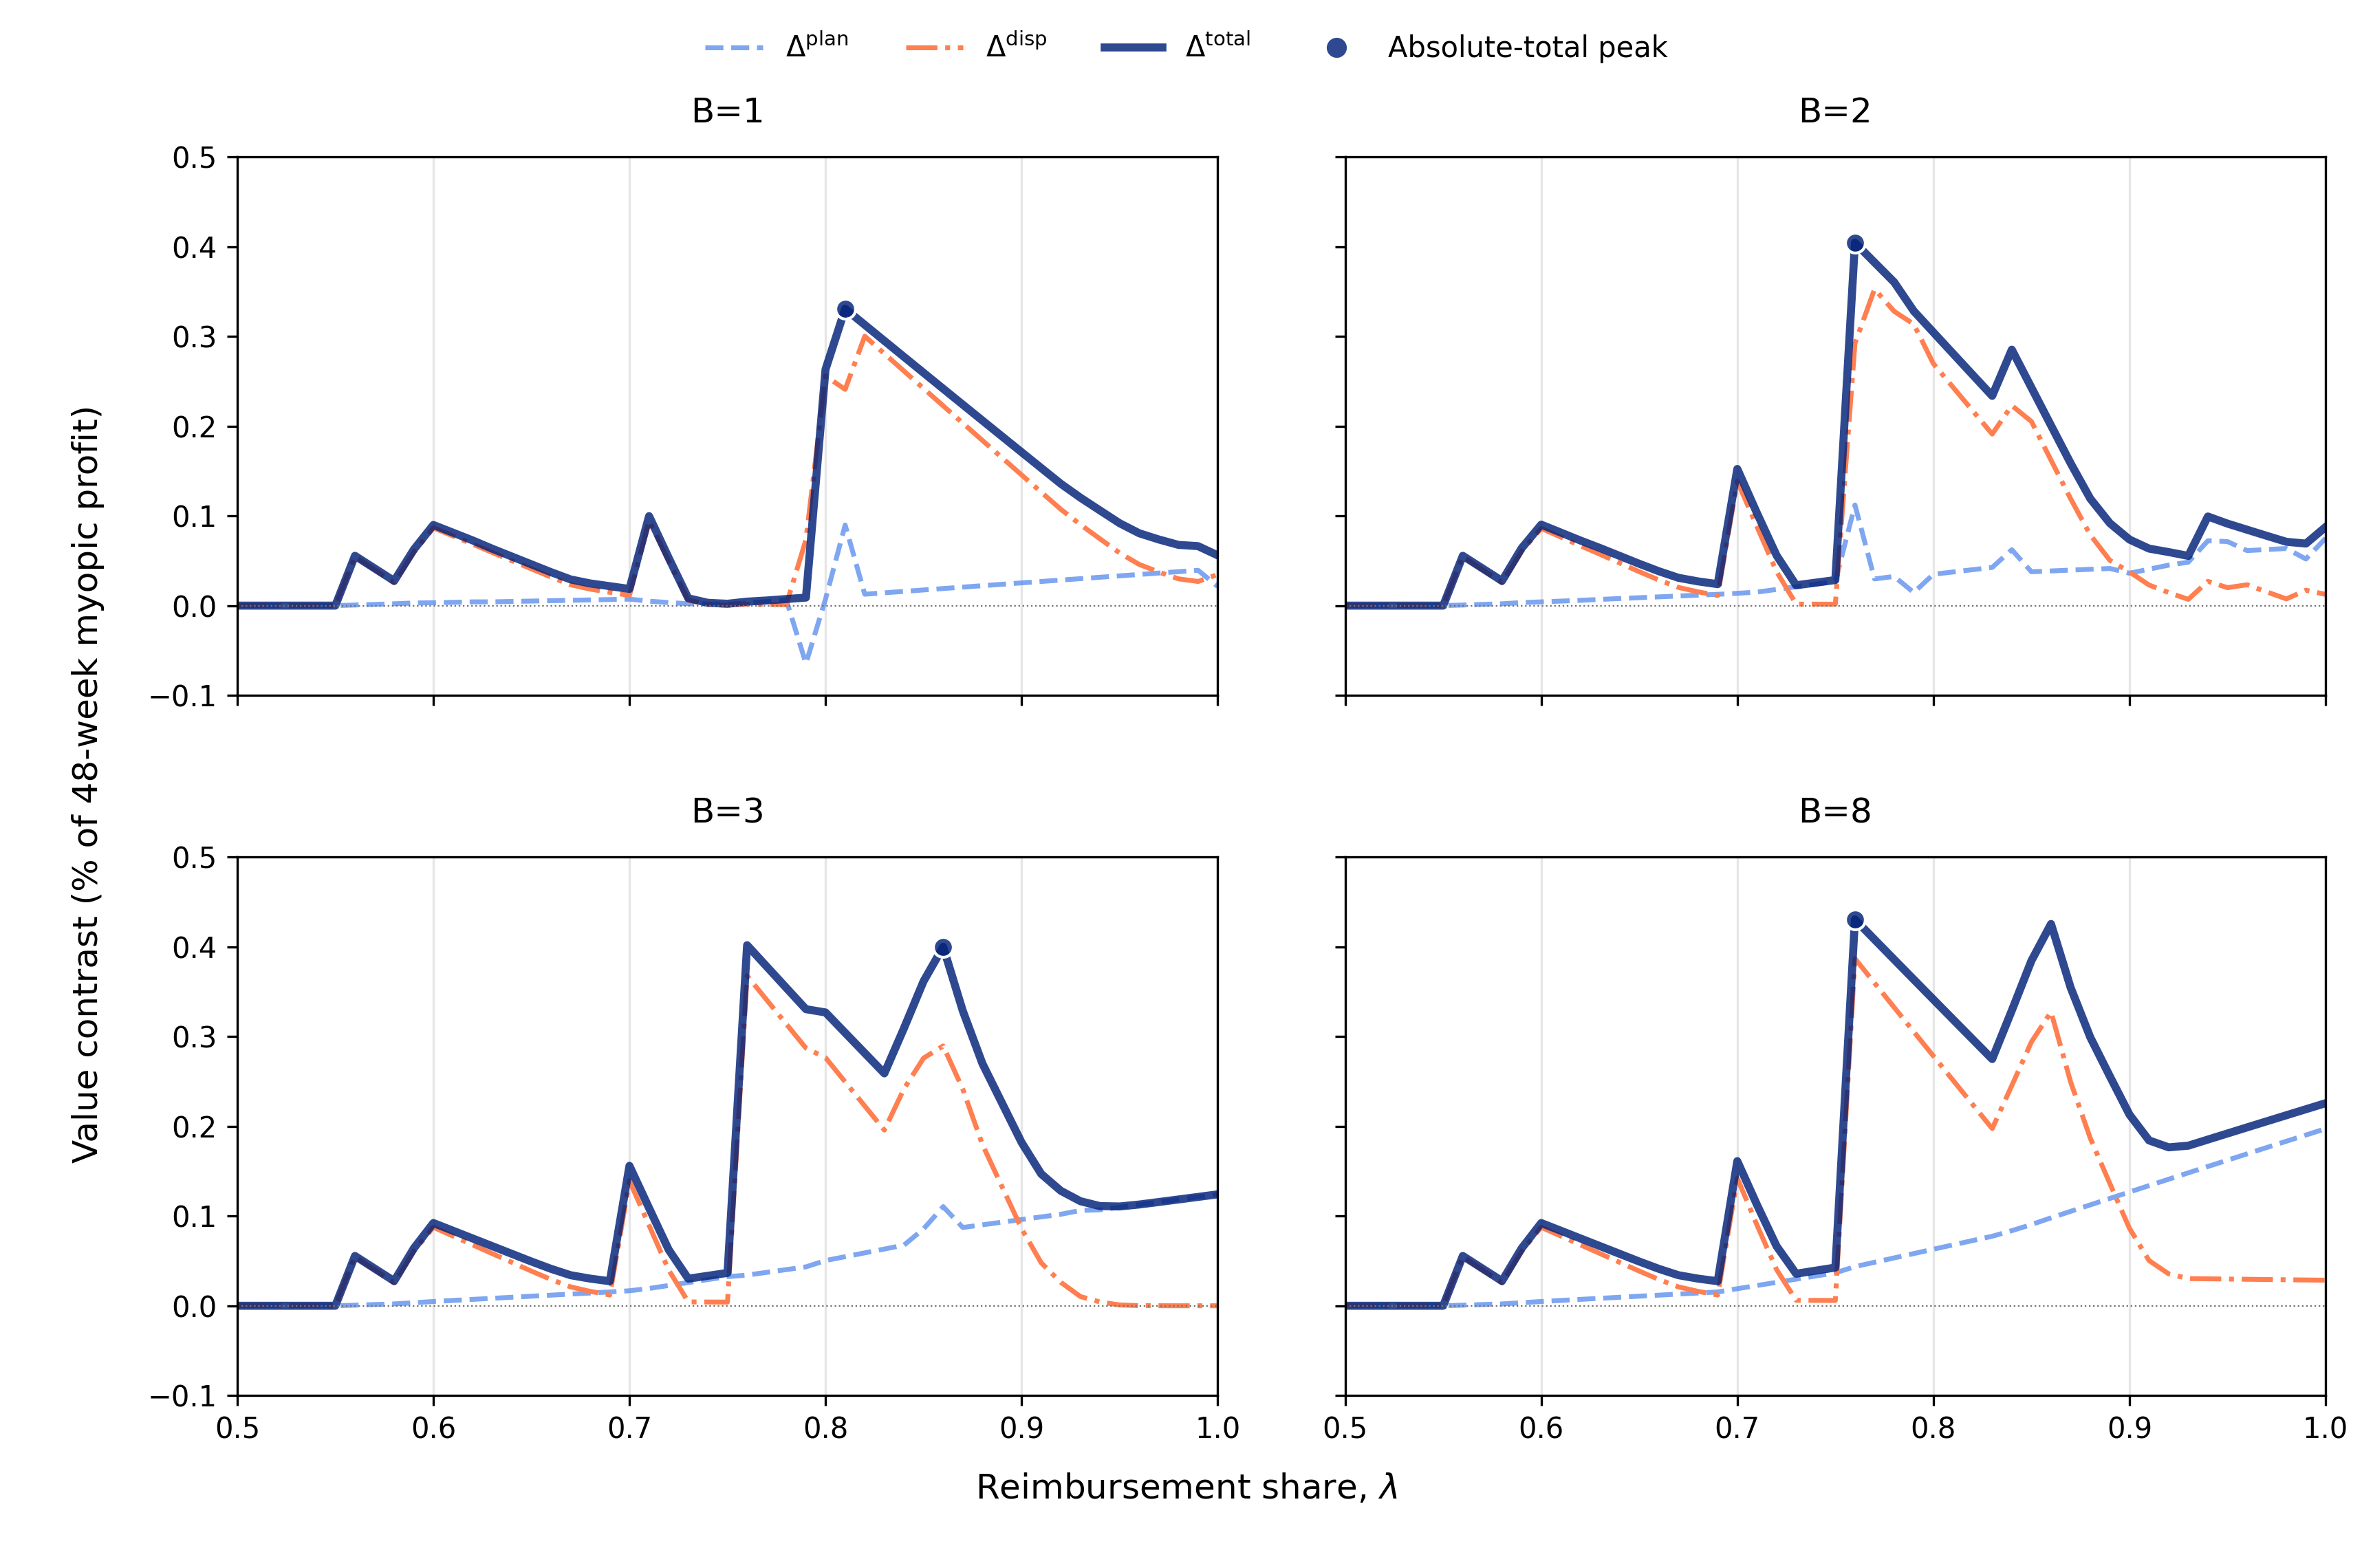

In [11]:
from IPython.display import Image, display
import subprocess

TABLE_DIR = PROJECT_ROOT / "results" / EB_VERSION / "tables"
FIGURE_DIR = PROJECT_ROOT / "results" / EB_VERSION / "figures"

# Canonical 48-week Figure 2 export and inline display.
subprocess.run(
    [sys.executable, str(SCRIPTS_DIR / "build_three_policy_48_week_figure.py")],
    cwd=PROJECT_ROOT,
    check=True,
)
figure2_path = FIGURE_DIR / "three_policy_components_by_capacity_lambda_050_to_100_48_week_normalized.png"
figure2_pdf_path = figure2_path.with_suffix(".pdf")
if not figure2_path.is_file() or not figure2_pdf_path.is_file():
    raise FileNotFoundError("Figure 2 export did not complete.")
display(Image(filename=str(figure2_path)))


### Table 3 - Largest dynamic-myopic policy differences by capacity

The displayed main-specification summary is the exact Task-8 export.

In [12]:
from build_paper_tables import build_paper_tables

paper_tables = build_paper_tables()
table3 = paper_tables["table3"]
if not table3["B"].tolist() == [1, 2, 3, 8]:
    raise AssertionError("Table 3 does not have the canonical capacity rows.")
display(table3)


,B,Peak $\\lambda$,$\\Delta^{total}$ (\\$),$\\Delta^{total}$ (% of 48-week myopic profit)
0,1,0.81,1930.644884,0.330670
1,2,0.76,2351.582781,0.404261
2,3,0.86,2342.935448,0.399845
3,8,0.76,2502.842114,0.430361


In [13]:
reporting_grid = pd.read_csv(TABLE_DIR / 'task8_three_policy_reporting_grid.csv')
additivity_error = (reporting_grid['delta_plan'] + reporting_grid['delta_disp'] - reporting_grid['delta_total']).abs().max()
assert additivity_error <= 1e-8, additivity_error
figure_peak = reporting_grid.loc[reporting_grid.groupby(['specification', 'capacity'])['delta_total'].idxmax()]
main_peaks = figure_peak.loc[figure_peak['specification'].eq('main')].sort_values('capacity')
print('Decomposition identity: PASS')
print(f'Maximum absolute error: {additivity_error:.2e}')
print('Diagnostic only: the final paper-facing normalization is 48-week myopic profit.')
display(main_peaks[['capacity', 'reimbursement_share', 'delta_total', 'delta_total_pct']].rename(columns={'delta_total_pct': 'delta_total_pct_12w'}))

Decomposition identity: PASS
Maximum absolute error: 4.55e-13
Diagnostic only: the final paper-facing normalization is 48-week myopic profit.


,capacity,reimbursement_share,delta_total,delta_total_pct_12w
81,1,0.81,1930.644884,1.217357
177,2,0.76,2351.582781,1.501942
288,3,0.86,2342.935448,1.456901
379,8,0.76,2502.842114,1.605747


### Table 5 - Conditional distribution of the total policy contrast across behavioral draws

In [14]:
paper_tables = build_paper_tables()
table5 = paper_tables["table5"]
table5_path = ROBUSTNESS_DIR / "fixed_calendar_behavioral_uncertainty_peak_summary.csv"
table5_expected = (
    pd.read_csv(table5_path)
    .loc[lambda frame: frame['component'].eq('delta_total_pct_myopic_48w')]
    .rename(columns={
        'capacity': 'B',
        'reimbursement_share': r'Peak $\lambda$',
        'p05': r'5th pct. (\%)',
        'p50': r'Median (\%)',
        'p95': r'95th pct. (\%)',
    })
    [['B', r'Peak $\lambda$', r'5th pct. (\%)', r'Median (\%)', r'95th pct. (\%)']]
    .sort_values('B')
    .reset_index(drop=True)
)
pd.testing.assert_frame_equal(
    table5.reset_index(drop=True),
    table5_expected,
    check_dtype=False,
    check_exact=False,
    rtol=0.0,
    atol=1e-12,
)
display(table5)


,B,Peak $\lambda$,5th pct. (\%),Median (\%),95th pct. (\%)
3,1,0.81,0.147084,0.321782,0.556944
7,2,0.76,0.225219,0.392864,0.618819
11,3,0.86,0.078751,0.378598,0.813616
15,8,0.76,0.249680,0.419126,0.641402


## Diagnostics / validation

### B=2 policy-switching rug (not a manuscript figure)

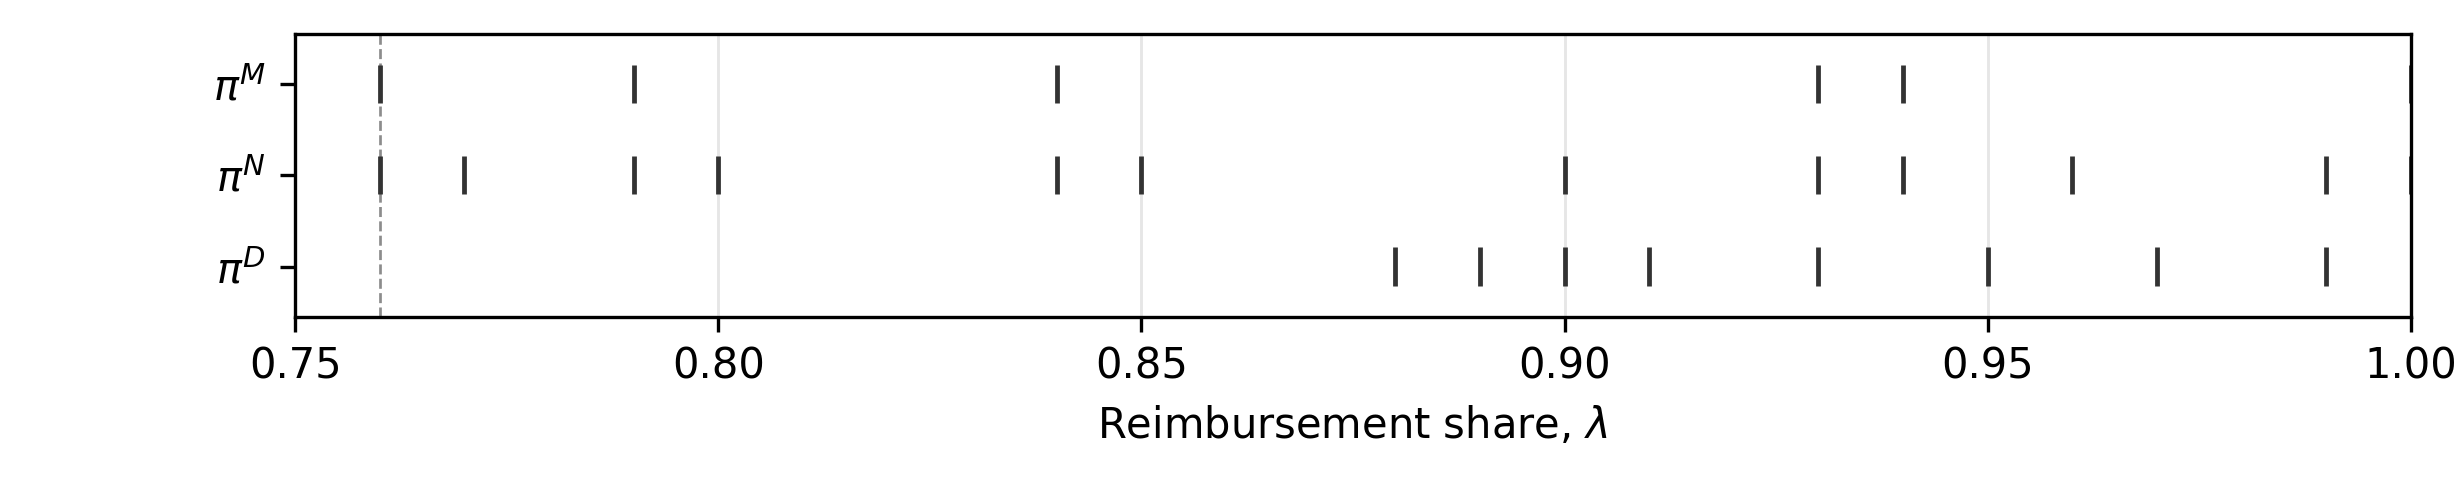

In [15]:
rug_path = FIGURE_DIR / "three_policy_switching_rug_B2.png"
if rug_path.is_file():
    display(Image(filename=str(rug_path)))
else:
    print("B=2 switching rug is not available; run the policy-figure builder.")


## Paper-output crosswalk

This check records the sole canonical notebook producer and exported location for each principal manuscript object.

In [16]:
crosswalk_records = [
    {"Paper object": "Table 1 - Selected products and empirical promotion support", "Canonical notebook": "03_descriptive_analysis", "Section": "Table 1", "Computed object": "paper_product_table", "Exported file(s)": "results/empirical_bayes/tables/paper_product_characteristics.csv/.tex", "required_exports": ["results/empirical_bayes/tables/paper_product_characteristics.csv", "results/empirical_bayes/tables/paper_product_characteristics.tex"]},
    {"Paper object": "Table 2 - Demand-model predictive performance", "Canonical notebook": "02_demand_estimation", "Section": "Table 2", "Computed object": "table2", "Exported file(s)": "results/final/tables/final_demand_model_comparison.csv", "required_exports": ["results/final/tables/final_demand_model_comparison.csv"]},
    {"Paper object": "Figure 1 - Empirical promotion support and calibrated post-promotion effects", "Canonical notebook": "05_product_calibration_and_action_support", "Section": "Figure 1", "Computed object": "build_eb_descriptive_figure output", "Exported file(s)": "results/empirical_bayes/figures/paper_promotion_depths_and_model_implied_post_effects.png/.pdf", "required_exports": ["results/empirical_bayes/figures/paper_promotion_depths_and_model_implied_post_effects.png", "results/empirical_bayes/figures/paper_promotion_depths_and_model_implied_post_effects.pdf"]},
    {"Paper object": "Figure 2 - Policy-value contrasts by capacity", "Canonical notebook": "08_robustness_and_uncertainty", "Section": "Figure 2", "Computed object": "build_three_policy_48_week_figure output", "Exported file(s)": "results/empirical_bayes_price_consistent/figures/three_policy_components_by_capacity_lambda_050_to_100_48_week_normalized.png/.pdf", "required_exports": ["results/empirical_bayes_price_consistent/figures/three_policy_components_by_capacity_lambda_050_to_100_48_week_normalized.png", "results/empirical_bayes_price_consistent/figures/three_policy_components_by_capacity_lambda_050_to_100_48_week_normalized.pdf"]},
    {"Paper object": "Table 3 - Largest dynamic-myopic policy differences by capacity", "Canonical notebook": "08_robustness_and_uncertainty", "Section": "Table 3", "Computed object": "table3", "Exported file(s)": "paper/tables/table3_main_policy_peaks.tex", "required_exports": ["paper/tables/table3_main_policy_peaks.tex"]},
    {"Paper object": "Table 4 - Robustness of peak total policy contrasts", "Canonical notebook": "08_robustness_and_uncertainty", "Section": "Table 4", "Computed object": "robustness_peak_table", "Exported file(s)": "paper/tables/table4_robustness_peaks.tex", "required_exports": ["paper/tables/table4_robustness_peaks.tex"]},
    {"Paper object": "Table 5 - Conditional distribution of the total policy contrast across behavioral draws", "Canonical notebook": "08_robustness_and_uncertainty", "Section": "Table 5", "Computed object": "table5", "Exported file(s)": "paper/tables/table5_behavioral_uncertainty.tex", "required_exports": ["paper/tables/table5_behavioral_uncertainty.tex"]},
]
for record in crosswalk_records:
    record["Current manuscript dependency"] = True
    record["Exact output agreement"] = "PASS" if all((PROJECT_ROOT / item).is_file() for item in record["required_exports"]) else "FAIL"
crosswalk = pd.DataFrame(crosswalk_records).drop(columns="required_exports")
if not crosswalk["Exact output agreement"].eq("PASS").all():
    raise FileNotFoundError("One or more principal paper outputs are missing; rerun their canonical producer.")
display(crosswalk)


,Paper object,Canonical notebook,Section,Computed object,Exported file(s),Current manuscript dependency,Exact output agreement
0,Table 1 - Selected products and empirical prom...,03_descriptive_analysis,Table 1,paper_product_table,results/empirical_bayes/tables/paper_product_c...,True,PASS
1,Table 2 - Demand-model predictive performance,02_demand_estimation,Table 2,table2,results/final/tables/final_demand_model_compar...,True,PASS
2,Figure 1 - Empirical promotion support and cal...,05_product_calibration_and_action_support,Figure 1,build_eb_descriptive_figure output,results/empirical_bayes/figures/paper_promotio...,True,PASS
3,Figure 2 - Policy-value contrasts by capacity,08_robustness_and_uncertainty,Figure 2,build_three_policy_48_week_figure output,results/empirical_bayes_price_consistent/figur...,True,PASS
4,Table 3 - Largest dynamic-myopic policy differ...,08_robustness_and_uncertainty,Table 3,table3,paper/tables/table3_main_policy_peaks.tex,True,PASS
5,Table 4 - Robustness of peak total policy cont...,08_robustness_and_uncertainty,Table 4,robustness_peak_table,paper/tables/table4_robustness_peaks.tex,True,PASS
6,Table 5 - Conditional distribution of the tota...,08_robustness_and_uncertainty,Table 5,table5,paper/tables/table5_behavioral_uncertainty.tex,True,PASS
